# Cache Access Trace Datasets Demo

This notebook demonstrates the cache access trace dataset artifact. It loads the standardized dataset JSON, inspects the schema, and visualizes dataset statistics.

**Artifact**: Cache Access Trace Datasets with Visual Embeddings
**Regimes**: `stationary_hot_clusters`, `sudden_popularity_shift`, `cold_start`

In [1]:
# Install dependencies - mirrors Colab package versions when running locally
import subprocess, sys
def _pip(*a):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# Non-Colab-only packages would go here. For this demo only stdlib + matplotlib are needed.

# Core scientific stack: pre-installed on Colab, install locally to match Colab versions
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
# Imports
import json
import os
from pathlib import Path
from typing import Any, Dict, List
import matplotlib.pyplot as plt

In [3]:
# Data loading helper with GitHub URL + local fallback
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-087852-visual-uncertainty-aware-conformal-cache/main/round-1/dataset-1/demo/mini_demo_data.json"

def load_data() -> Dict[str, Any]:
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {len(data['datasets'])} dataset group(s)")

Loaded 1 dataset group(s)


## Config

Tunable parameters for the demo. Values are set to the absolute minimum for fast execution.

In [5]:
# Config parameters - minimum demo values
DATASETS_TO_SHOW = 1          # number of dataset regimes to process
MAX_EXAMPLES_PER_DATASET = 10 # maximum examples to inspect per dataset

## Inspect Dataset Schema

This section loads the raw JSON and prints one example along with metadata fields.

In [6]:
# Show schema for the first available dataset
dataset_group = data['datasets'][0]
print('Dataset name:', dataset_group['dataset'])
print('Example count:', len(dataset_group['examples']))
example = dataset_group['examples'][0]
print('\nExample keys:', list(example.keys()))
print('metadata_fold:', example['metadata_fold'])
print('metadata_feature_names:', example['metadata_feature_names'])
print('output:', example['output'])

# Parse the input feature JSON to show structure
features = json.loads(example['input'])
print('\nParsed input features:', list(features.keys()))
print('embedding dim:', len(features['embedding']))
print('popularity_count:', features['popularity_count'])
print('cluster_id:', features['cluster_id'])
print('timestamp:', features['timestamp'])
print('image_file:', features['image_file'])

Dataset name: stationary_hot_clusters
Example count: 5

Example keys: ['input', 'output', 'metadata_fold', 'metadata_feature_names']
metadata_fold: 0
metadata_feature_names: ['embedding', 'popularity_count', 'cluster_id', 'timestamp', 'image_file']
output: 8

Parsed input features: ['embedding', 'popularity_count', 'cluster_id', 'timestamp', 'image_file']
embedding dim: 512
popularity_count: 132
cluster_id: 0
timestamp: 0
image_file: image_00315.jpg


## Dataset Summary

Summarize counts, folds, and feature distributions across the selected datasets.

In [7]:
# Summarize dataset statistics from the loaded JSON
import pandas as pd

summary_rows = []
for group in data['datasets'][:DATASETS_TO_SHOW]:
    examples = group['examples']
    parsed_inputs = [json.loads(ex['input']) for ex in examples[:MAX_EXAMPLES_PER_DATASET]]
    popularity_counts = [inp['popularity_count'] for inp in parsed_inputs]
    timestamps = [inp['timestamp'] for inp in parsed_inputs]
    cluster_ids = [inp['cluster_id'] for inp in parsed_inputs]
    summary_rows.append({
        'dataset': group['dataset'],
        'examples': len(examples),
        'shown_examples': min(len(examples), MAX_EXAMPLES_PER_DATASET),
        'unique_folds': sorted({ex['metadata_fold'] for ex in examples[:MAX_EXAMPLES_PER_DATASET]}),
        'min_popularity': min(popularity_counts),
        'max_popularity': max(popularity_counts),
        'min_timestamp': min(timestamps),
        'max_timestamp': max(timestamps),
        'unique_clusters_shown': len(set(cluster_ids))
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,dataset,examples,shown_examples,unique_folds,min_popularity,max_popularity,min_timestamp,max_timestamp,unique_clusters_shown
0,stationary_hot_clusters,5,5,[0],2,701,0,4,4


## Visualization

Plot simple statistics from the standardized dataset JSON.

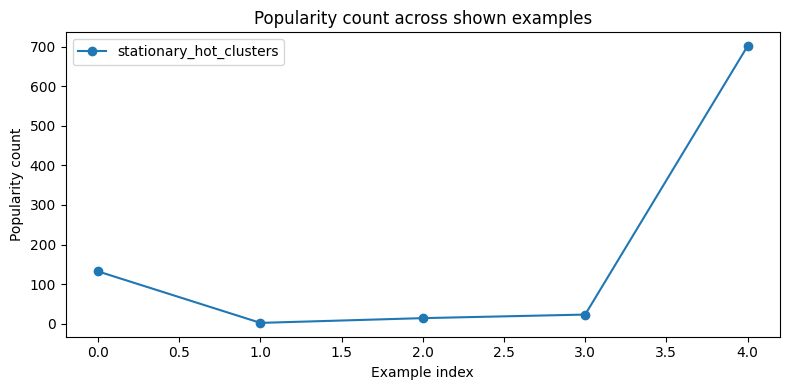

In [8]:
# Visualize popularity count distribution from parsed inputs
plt.figure(figsize=(8, 4))
for group in data['datasets'][:DATASETS_TO_SHOW]:
    examples = group['examples'][:MAX_EXAMPLES_PER_DATASET]
    parsed_inputs = [json.loads(ex['input']) for ex in examples]
    popularity_counts = [inp['popularity_count'] for inp in parsed_inputs]
    plt.plot(popularity_counts, marker='o', label=group['dataset'])

plt.xlabel('Example index')
plt.ylabel('Popularity count')
plt.title('Popularity count across shown examples')
plt.legend()
plt.tight_layout()
plt.show()